# Alzheimer ELSI-Brasil

- pessoas sem diagnóstico médico relatado de Alzheimer (`n63 = 0`)
- pessoas com diagnóstico médico relatado de Alzheimer (`n63 = 1`)

As respostas `n63 = 9` são “não sabe/não respondeu” e serão retiradas da comparação.

1. **Características que sempre devem ser consideradas:** idade, sexo, região, zona, escolaridade, raça/cor e renda.
2. **Possíveis fatores ou contextos anteriores:** infância, atividade física, tabagismo, álcool, condições cardiovasculares, visão, audição, depressão e rede social.
3. **Acesso ao diagnóstico:** plano de saúde, consultas e facilidade de acesso ao serviço.
4. **Marcadores clínicos ou possíveis consequências:** funcionalidade, cognição, medicamentos e outros problemas de memória.

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## Base

In [2]:
base = pd.read_csv('ELSI Portugues (3a onda).csv', compression="infer", low_memory=False)

print("Número de participantes:", base.shape[0])
print("Número de colunas:", base.shape[1])

Número de participantes: 10773
Número de colunas: 866


## Inventário

In [3]:
nomes_blocos = {
    "a": "Bloco A — Estrutura domiciliar",
    "b": "Bloco B — Bens e patrimônio",
    "c": "Bloco C — Despesas do domicílio",
    "d": "Bloco D — Renda",
    "e": "Bloco E — Características sociodemográficas",
    "f": "Bloco F — Vizinhança",
    "g": "Bloco G — Discriminação",
    "h": "Bloco H — Infância e história de vida",
    "i": "Bloco I — Trabalho e aposentadoria",
    "k": "Bloco K — Ajuda familiar",
    "l": "Bloco L — Comportamentos de saúde",
    "m": "Bloco M — Saúde da mulher",
    "n": "Bloco N — Saúde e doenças",
    "o": "Bloco O — Saúde bucal",
    "p": "Bloco P — Funcionalidade",
    "q": "Bloco Q — Cognição",
    "r": "Bloco R — Sintomas depressivos",
    "s": "Bloco S — Relações sociais",
    "t": "Bloco T — Medicamentos",
    "u": "Bloco U — Uso de serviços de saúde"
}

variaveis_identificacao = [
    "id3",
    "iddom3",
    "upa",
    "peso_calibrado",
    "estrato",
    "regiao",
    "zona",
    "nmoradores",
    "sexo",
    "idade",
    "rendadom",
    "rendadompc"
]

linhas_inventario = []


for coluna in base.columns:

    # Variáveis gerais
    if coluna in variaveis_identificacao:
        bloco = "Identificação e informações gerais"

    elif coluna.startswith("idade"):
        bloco = "Idade dos outros moradores"

    elif coluna.startswith("sexo"):
        bloco = "Sexo dos outros moradores"

    elif coluna.startswith("relacao"):
        bloco = "Relação entre os moradores"

    elif coluna.startswith("mf"):
        bloco = "Medidas físicas e testes"

    elif coluna.startswith("covid"):
        bloco = "Módulo COVID-19"

    else:
        primeira_letra = coluna[0].lower()

        if primeira_letra in nomes_blocos:
            bloco = nomes_blocos[primeira_letra]

        else:
            bloco = "Outras variáveis"


    linhas_inventario.append({
        "Variável": coluna,
        "Bloco": bloco,
        "Tipo de dado": str(base[coluna].dtype),
        "Quantidade preenchida": base[coluna].notna().sum(),
        "Quantidade ausente": base[coluna].isna().sum(),
        "Percentual ausente": base[coluna].isna().mean() * 100
    })



inventario = pd.DataFrame(linhas_inventario)
display(inventario.head(30))


resumo_blocos = (
    inventario
    .groupby("Bloco")
    .size()
    .reset_index(name="Número de variáveis")
)


resumo_blocos = resumo_blocos.sort_values(
    by="Número de variáveis",
    ascending=False
)


display(resumo_blocos)
print("Total de variáveis encontradas:", len(inventario))

,Variável,Bloco,Tipo de dado,Quantidade preenchida,Quantidade ausente,Percentual ausente
0,id3,Identificação e informações gerais,int64,10773,0,0.00
1,iddom3,Identificação e informações gerais,int64,10773,0,0.00
2,upa,Identificação e informações gerais,int64,10773,0,0.00
3,peso_calibrado,Identificação e informações gerais,float64,10773,0,0.00
4,estrato,Identificação e informações gerais,int64,10773,0,0.00
5,regiao,Identificação e informações gerais,int64,10773,0,0.00
6,zona,Identificação e informações gerais,int64,10773,0,0.00
7,nmoradores,Identificação e informações gerais,int64,10773,0,0.00
8,ar10,Bloco A — Estrutura domiciliar,float64,10772,1,0.01
9,ar8,Bloco A — Estrutura domiciliar,float64,10772,1,0.01


,Bloco,Número de variáveis
12,Bloco N — Saúde e doenças,162
19,Bloco U — Uso de serviços de saúde,97
14,Bloco P — Funcionalidade,74
10,Bloco L — Comportamentos de saúde,61
13,Bloco O — Saúde bucal,47
1,Bloco B — Bens e patrimônio,41
17,Bloco S — Relações sociais,39
8,Bloco I — Trabalho e aposentadoria,34
23,Módulo COVID-19,29
7,Bloco H — Infância e história de vida,26


Total de variáveis encontradas: 866


In [8]:
print(inventario.columns.tolist())

['Variável', 'Bloco', 'Tipo de dado', 'Quantidade preenchida', 'Quantidade ausente', 'Percentual ausente']


In [10]:
for bloco, grupo in inventario.groupby("Bloco", sort=False):
    print(f"\n{bloco} — {len(grupo)} colunas")
    print(", ".join(grupo["Variável"].tolist()))


Identificação e informações gerais — 12 colunas
id3, iddom3, upa, peso_calibrado, estrato, regiao, zona, nmoradores, sexo, idade, rendadom, rendadompc

Bloco A — Estrutura domiciliar — 24 colunas
ar10, ar8, a1, a2, a3, a4, a5, a6, a7, a8, a8_0, a8_1, a9, a10, a11, a12, a13, a14_1, a14_2, a14_3, a14_4, a15, a16, a17

Idade dos outros moradores — 11 colunas
idade2, idade3, idade4, idade5, idade6, idade7, idade8, idade9, idade10, idade11, idade12

Sexo dos outros moradores — 11 colunas
sexo2, sexo3, sexo4, sexo5, sexo6, sexo7, sexo8, sexo9, sexo10, sexo11, sexo12

Relação entre os moradores — 12 colunas
relacao2, relacao3, relacao4, relacao5, relacao6, relacao7, relacao8, relacao9, relacao10, relacao11, relacao12, relacao

Bloco C — Despesas do domicílio — 2 colunas
c16, c17

Bloco B — Bens e patrimônio — 41 colunas
b1, b2, b3, b4, b5, b6, b7, b8, b9, b10, b10_1, b10_2, b11, b12, b13, b14, b15, b16, b17, b18, b19, b20, b21, b22, b23, b24, b25, b26, b27, b28, b29, b30, b31, b31_1, b33, b3

Mantemos apenas `0` e `1`.

In [11]:
print(base["n63"].value_counts(dropna=False).sort_index())

dados = base.loc[base["n63"].isin([0, 1])].copy()
dados["Alzheimer"] = dados["n63"].map({0: "Não", 1: "Sim"})

print("\nParticipantes mantidos:", len(dados))
print("Participantes retirados por resposta 9:", int((base["n63"] == 9).sum()))

n63
0    10569
1      186
9       18
Name: count, dtype: int64

Participantes mantidos: 10755
Participantes retirados por resposta 9: 18


In [12]:
dados["Sexo"] = dados["sexo"].map({
    0: "Feminino",
    1: "Masculino",
})

dados["Região"] = dados["regiao"].map({
    1: "Norte",
    2: "Nordeste",
    3: "Sudeste",
    4: "Sul",
    5: "Centro-Oeste",
})

dados["Zona"] = dados["zona"].map({
    1: "Urbana",
    2: "Rural",
})

dados["Situação conjugal"] = dados["e7"].map({
    1: "Solteiro(a)",
    2: "Casado(a)/união estável",
    3: "Divorciado(a)/separado(a)",
    4: "Viúvo(a)",
})

dados["Raça/cor"] = dados["e9"].map({
    1: "Branca",
    2: "Preta",
    3: "Parda",
    4: "Amarela",
    5: "Indígena",
})

dados["Faixa etária"] = pd.cut(
    dados["idade"],
    bins=[49, 59, 69, 79, np.inf],
    labels=["50–59", "60–69", "70–79", "80+"],
)

def agrupar_escolaridade(codigo):
    if codigo == 1:
        return "Nunca estudou"
    if codigo in [2, 3, 4, 5]:
        return "1ª–4ª série"
    if codigo in [6, 7, 8, 9]:
        return "5ª–8ª série"
    if codigo in [10, 11, 12, 13]:
        return "Ensino médio/supletivo"
    if codigo == 14:
        return "Superior incompleto"
    if codigo in [15, 16, 17, 18]:
        return "Superior completo/pós"
    return np.nan

dados["Escolaridade agrupada"] = dados["e22"].apply(agrupar_escolaridade)

renda_valida = dados["rendadompc"].where(dados["rendadompc"] >= 0)

dados["Faixa de renda"] = pd.qcut(
    renda_valida,
    q=4,
    labels=["25% mais baixa", "Baixa-média", "Média-alta", "25% mais alta"],
    duplicates="drop",
)

display(
    dados[
        ["idade", "Faixa etária", "Sexo", "Região", "Zona",
         "Situação conjugal", "Raça/cor", "Escolaridade agrupada",
         "rendadompc", "Faixa de renda", "Alzheimer"]
    ].head()
)

,idade,Faixa etária,Sexo,Região,Zona,Situação conjugal,Raça/cor,Escolaridade agrupada,rendadompc,Faixa de renda,Alzheimer
0,59,50–59,Feminino,Sudeste,Urbana,Divorciado(a)/separado(a),Parda,5ª–8ª série,"1,320.00",Baixa-média,Não
1,81,80+,Feminino,Sudeste,Urbana,Viúvo(a),Branca,1ª–4ª série,"1,040.00",Baixa-média,Não
2,89,80+,Feminino,Sudeste,Urbana,Viúvo(a),Parda,1ª–4ª série,NaN,NaN,Não
3,78,70–79,Masculino,Sudeste,Urbana,Casado(a)/união estável,Parda,Ensino médio/supletivo,NaN,NaN,Não
4,85,80+,Feminino,Sudeste,Urbana,Viúvo(a),Parda,1ª–4ª série,NaN,NaN,Não


### `tabela_por_categoria`

Mostra, em cada categoria:

- participantes;
- pessoas com Alzheimer;
- percentual simples;
- percentual ponderado pelo peso da pesquisa.

### `comparar_variaveis_binarias`

Compara a porcentagem que respondeu “sim” a várias perguntas entre os grupos com e sem Alzheimer.


In [42]:
def percentual_ponderado(grupo):
    grupo = grupo.dropna(subset=["peso_calibrado", "n63"])

    if len(grupo) == 0 or grupo["peso_calibrado"].sum() == 0:
        return np.nan

    return np.average(
        grupo["n63"],
        weights=grupo["peso_calibrado"],
    ) * 100


def tabela_por_categoria(coluna, ordem=None, minimo=10):
    temp = dados.loc[dados[coluna].notna(), [coluna, "n63", "peso_calibrado"]].copy()

    linhas = []

    for categoria, grupo in temp.groupby(coluna, observed=True, dropna=False):
        linhas.append({
            coluna: categoria,
            "Participantes": len(grupo),
            "Com Alzheimer": int(grupo["n63"].sum()),
            "Percentual simples": grupo["n63"].mean() * 100,
            "Percentual ponderado": percentual_ponderado(grupo),
        })

    tabela = pd.DataFrame(linhas)
    tabela = tabela.loc[tabela["Participantes"] >= minimo].copy()

    if ordem is not None:
        tabela[coluna] = pd.Categorical(
            tabela[coluna],
            categories=ordem,
            ordered=True,
        )
        tabela = tabela.sort_values(coluna)

    return tabela.reset_index(drop=True)


def comparar_variaveis_binarias(dicionario):
    linhas = []

    nomes_alzheimer = {
        0: "Não tem Alzheimer",
        1: "Tem Alzheimer",
        "Não": "Não tem Alzheimer",
        "Sim": "Tem Alzheimer",
    }

    for variavel, descricao in dicionario.items():
        if variavel not in dados.columns:
            continue

        temp = dados.loc[
            dados[variavel].isin([0, 1]),
            ["Alzheimer", variavel],
        ].copy()

        temp["Grupo"] = temp["Alzheimer"].map(nomes_alzheimer)
        temp = temp.dropna(subset=["Grupo"])

        for grupo, parte in temp.groupby("Grupo"):
            linhas.append({
                "Variável": variavel,
                "Descrição": descricao,
                "Grupo": grupo,
                "Percentual que respondeu sim": parte[variavel].mean() * 100,
            })

    longa = pd.DataFrame(linhas)

    tabela = longa.pivot_table(
        index=["Variável", "Descrição"],
        columns="Grupo",
        values="Percentual que respondeu sim",
    ).reset_index()

    tabela.columns.name = None

    if (
        "Não tem Alzheimer" in tabela.columns
        and "Tem Alzheimer" in tabela.columns
    ):
        tabela["Diferença em pontos percentuais"] = (
            tabela["Tem Alzheimer"]
            - tabela["Não tem Alzheimer"]
        )

    colunas_numericas = [
        "Não tem Alzheimer",
        "Tem Alzheimer",
        "Diferença em pontos percentuais",
    ]

    tabela[colunas_numericas] = tabela[colunas_numericas].round(2)

    return tabela.sort_values(
        "Diferença em pontos percentuais",
        ascending=False,
    ).reset_index(drop=True)


def grafico_percentual(tabela, coluna, titulo):
    tabela_grafico = tabela.set_index(coluna)["Percentual ponderado"]
    tabela_grafico.plot(kind="bar")
    plt.title(titulo)
    plt.xlabel(coluna)
    plt.ylabel("Percentual ponderado com Alzheimer (%)")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


def resumo_numerico(coluna, minimo=None, maximo=None):
    temp = dados[["Alzheimer", coluna]].copy()
    temp[coluna] = pd.to_numeric(temp[coluna], errors="coerce")

    if minimo is not None:
        temp = temp.loc[temp[coluna] >= minimo]

    if maximo is not None:
        temp = temp.loc[temp[coluna] <= maximo]

    return (
        temp.groupby("Alzheimer")[coluna]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .rename(columns={
            "count": "Quantidade válida",
            "mean": "Média",
            "median": "Mediana",
            "std": "Desvio padrão",
            "min": "Mínimo",
            "max": "Máximo",
        })
    )

# Características básicas
Quantidade e percentual de diagnósticos

In [14]:
contagem = dados["Alzheimer"].value_counts()
percentual = dados["Alzheimer"].value_counts(normalize=True).mul(100)

resumo_geral = pd.DataFrame({
    "Número de pessoas": contagem,
    "Percentual simples": percentual,
})

display(resumo_geral)

,Número de pessoas,Percentual simples
Alzheimer,,
Não,10569,98.27
Sim,186,1.73


## Idade

,Faixa etária,Participantes,Com Alzheimer,Percentual simples,Percentual ponderado
0,50–59,2201,6,0.27,0.19
1,60–69,4058,21,0.52,0.47
2,70–79,2915,55,1.89,1.68
3,80+,1581,104,6.58,6.67


,Quantidade válida,Média,Mediana,Desvio padrão,Mínimo,Máximo
Alzheimer,,,,,,
Não,10569,68.07,67.00,9.78,50,119
Sim,186,79.76,81.00,9.26,53,100


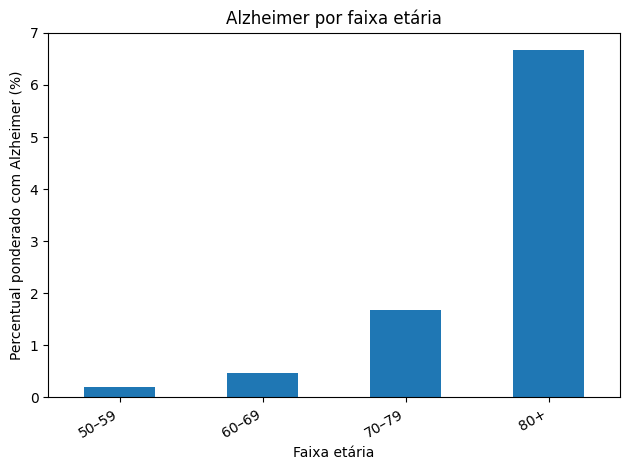

In [16]:
tabela_idade = tabela_por_categoria(
    "Faixa etária",
    ordem=["50–59", "60–69", "70–79", "80+"],
)

display(tabela_idade)
display(resumo_numerico("idade"))

grafico_percentual(
    tabela_idade,
    "Faixa etária",
    "Alzheimer por faixa etária",
)

## Sexo, região e zona


Sexo


,Sexo,Participantes,Com Alzheimer,Percentual simples,Percentual ponderado
0,Feminino,6604,131,1.98,1.29
1,Masculino,4151,55,1.32,0.73


Região


,Região,Participantes,Com Alzheimer,Percentual simples,Percentual ponderado
0,Norte,798,9,1.13,0.70
1,Nordeste,2867,52,1.81,1.05
2,Sudeste,4433,84,1.89,1.10
3,Sul,1455,23,1.58,1.06
4,Centro-Oeste,1202,18,1.50,0.89


Zona


,Zona,Participantes,Com Alzheimer,Percentual simples,Percentual ponderado
0,Urbana,9053,153,1.69,1.03
1,Rural,1702,33,1.94,1.09


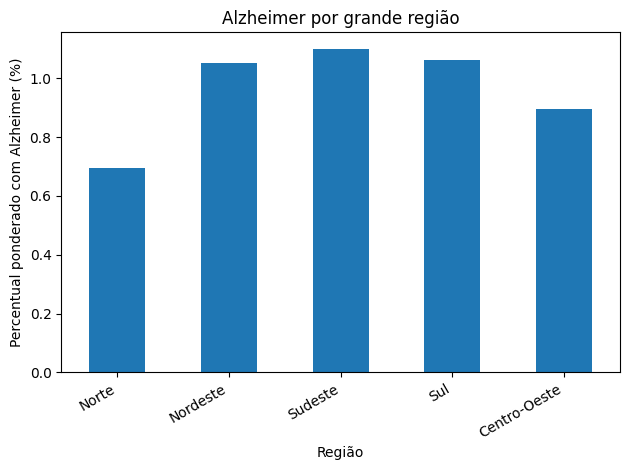

In [17]:
tabela_sexo = tabela_por_categoria(
    "Sexo",
    ordem=["Feminino", "Masculino"],
)

tabela_regiao = tabela_por_categoria(
    "Região",
    ordem=["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"],
)

tabela_zona = tabela_por_categoria(
    "Zona",
    ordem=["Urbana", "Rural"],
)

print("Sexo")
display(tabela_sexo)

print("Região")
display(tabela_regiao)

print("Zona")
display(tabela_zona)

grafico_percentual(
    tabela_regiao,
    "Região",
    "Alzheimer por grande região",
)

# Condições sociodemográficas e curso de vida

### Situação conjugal, raça/cor, escolaridade e renda


Situação conjugal


,Situação conjugal,Participantes,Com Alzheimer,Percentual simples,Percentual ponderado
0,Casado(a)/união estável,5558,51,0.92,0.53
1,Divorciado(a)/separado(a),1151,13,1.13,0.71
2,Solteiro(a),1504,23,1.53,0.96
3,Viúvo(a),2542,99,3.89,3.01


Raça/cor


,Raça/cor,Participantes,Com Alzheimer,Percentual simples,Percentual ponderado
0,Amarela,24,2,8.33,5.51
1,Branca,4505,90,2.00,1.14
2,Indígena,52,0,0.00,0.00
3,Parda,4838,82,1.69,1.08
4,Preta,1299,12,0.92,0.51


Escolaridade


,Escolaridade agrupada,Participantes,Com Alzheimer,Percentual simples,Percentual ponderado
0,Nunca estudou,1603,57,3.56,2.70
1,1ª–4ª série,4023,80,1.99,1.26
2,5ª–8ª série,2142,24,1.12,0.69
3,Ensino médio/supletivo,2008,11,0.55,0.26
4,Superior incompleto,150,1,0.67,0.22
5,Superior completo/pós,742,9,1.21,0.83


Renda domiciliar per capita


,Faixa de renda,Participantes,Com Alzheimer,Percentual simples,Percentual ponderado
0,25% mais baixa,2488,33,1.33,0.80
1,Baixa-média,3551,61,1.72,1.17
2,Média-alta,1472,33,2.24,1.29
3,25% mais alta,2441,42,1.72,0.93


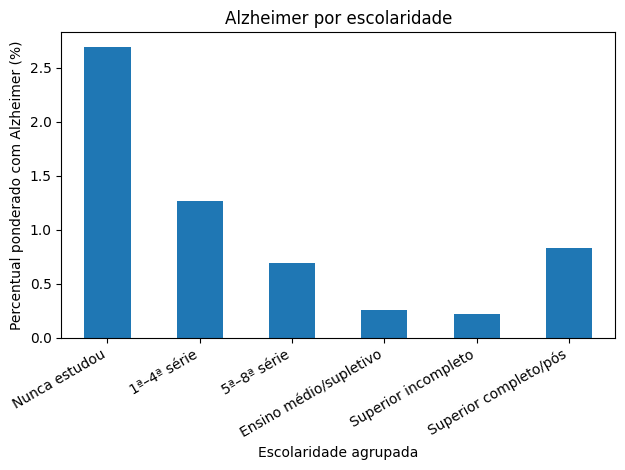

In [18]:
tabela_conjugal = tabela_por_categoria("Situação conjugal")
tabela_raca = tabela_por_categoria("Raça/cor")
tabela_escolaridade = tabela_por_categoria(
    "Escolaridade agrupada",
    ordem=[
        "Nunca estudou",
        "1ª–4ª série",
        "5ª–8ª série",
        "Ensino médio/supletivo",
        "Superior incompleto",
        "Superior completo/pós",
    ],
)
tabela_renda = tabela_por_categoria(
    "Faixa de renda",
    ordem=["25% mais baixa", "Baixa-média", "Média-alta", "25% mais alta"],
)

print("Situação conjugal")
display(tabela_conjugal)

print("Raça/cor")
display(tabela_raca)

print("Escolaridade")
display(tabela_escolaridade)

print("Renda domiciliar per capita")
display(tabela_renda)

grafico_percentual(
    tabela_escolaridade,
    "Escolaridade agrupada",
    "Alzheimer por escolaridade",
)

## Infância


In [19]:
infancia_binarias = {
    "e6": "Morou em área rural até os 15 anos",
    "h6": "Estava na escola aos 10 anos",
    "h8": "Existiam livros em casa aos 10 anos",
    "h12": "Faltou à escola por saúde durante um mês ou mais",
    "h21": "Teve dificuldade visual na infância",
    "h24": "Foi dormir com fome por falta de comida na infância",
}

tabela_infancia = comparar_variaveis_binarias(infancia_binarias)
display(tabela_infancia)

dados["Situação financeira na infância"] = dados["h10"].map({
    1: "Bem financeiramente",
    2: "Dentro da média",
    3: "Pobre",
    4: "Variava muito",
})

tabela_h10 = tabela_por_categoria("Situação financeira na infância")
display(tabela_h10)

Alzheimer,Variável,Descrição,Não,Sim,Diferença em pontos percentuais
0,e6,Morou em área rural até os 15 anos,52.55,59.78,7.23
1,h21,Teve dificuldade visual na infância,3.97,4.57,0.61
2,h24,Foi dormir com fome por falta de comida na inf...,23.71,24.28,0.57
3,h12,Faltou à escola por saúde durante um mês ou mais,9.68,9.76,0.08
4,h8,Existiam livros em casa aos 10 anos,39.75,34.32,-5.44
5,h6,Estava na escola aos 10 anos,72.65,58.89,-13.76


,Situação financeira na infância,Participantes,Com Alzheimer,Percentual simples,Percentual ponderado
0,Bem financeiramente,400,5,1.25,0.68
1,Dentro da média,2571,38,1.48,0.87
2,Pobre,6595,121,1.83,1.08
3,Variava muito,1101,17,1.54,1.11


# Vizinhança e ambiente

### Condições da vizinhança


In [24]:
vizinhanca_binarias = {
    "f3": "Lixo, entulho ou mato alto na vizinhança",
    "f7": "Medo de cair por defeitos nas calçadas",
    "f8": "Preocupação com dificuldade para subir no transporte",
    "f10_3": "Existem árvores que tornam o ambiente agradável",
}

tabela_vizinhanca = comparar_variaveis_binarias(vizinhanca_binarias)
display(tabela_vizinhanca)

dados["Segurança da vizinhança"] = dados["f5"].map({
    1: "Muito insegura",
    2: "Nem segura nem insegura",
    3: "Muito segura",
})

dados["Avaliação das calçadas"] = dados["f10_1"].map({
    1: "Muito boa",
    2: "Boa",
    3: "Regular",
    4: "Ruim",
    5: "Muito ruim",
})

dados["Avaliação da iluminação"] = dados["f10_2"].map({
    1: "Muito boa",
    2: "Boa",
    3: "Regular",
    4: "Ruim",
    5: "Muito ruim",
})

display(tabela_por_categoria("Segurança da vizinhança"))
display(tabela_por_categoria("Avaliação das calçadas"))
display(tabela_por_categoria("Avaliação da iluminação"))

,Variável,Descrição,Não tem Alzheimer,Tem Alzheimer,Diferença em pontos percentuais
0,f8,Preocupação com dificuldade para subir no tran...,32.51,70.63,38.11
1,f7,Medo de cair por defeitos nas calçadas,40.25,68.28,28.02
2,f10_3,Existem árvores que tornam o ambiente agradável,70.99,77.70,6.71
3,f3,"Lixo, entulho ou mato alto na vizinhança",21.39,20.27,-1.12


,Segurança da vizinhança,Participantes,Com Alzheimer,Percentual simples,Percentual ponderado
0,Muito insegura,1343,26,1.94,1.09
1,Muito segura,1139,19,1.67,1.00
2,Nem segura nem insegura,6368,103,1.62,0.98


,Avaliação das calçadas,Participantes,Com Alzheimer,Percentual simples,Percentual ponderado
0,Boa,4683,78,1.67,0.94
1,Muito boa,442,8,1.81,0.88
2,Muito ruim,300,2,0.67,0.62
3,Regular,2802,49,1.75,1.08
4,Ruim,627,10,1.59,1.22


,Avaliação da iluminação,Participantes,Com Alzheimer,Percentual simples,Percentual ponderado
0,Boa,6832,117,1.71,1.02
1,Muito boa,850,14,1.65,0.81
2,Muito ruim,19,0,0.00,0.00
3,Regular,976,14,1.43,1.06
4,Ruim,190,3,1.58,0.84


# Comportamentos em saúde

### Atividade física e tempo sentado


In [27]:
dados["Atividade vigorosa habitual"] = dados["l1"].map({
    1: "Mais de 1 vez/semana",
    2: "1 vez/semana",
    3: "1–3 vezes/mês",
    4: "Raramente/nunca",
})

dados["Atividade moderada habitual"] = dados["l2"].map({
    1: "Mais de 1 vez/semana",
    2: "1 vez/semana",
    3: "1–3 vezes/mês",
    4: "Raramente/nunca",
})

display(tabela_por_categoria("Atividade vigorosa habitual"))
display(tabela_por_categoria("Atividade moderada habitual"))

print("Dias de caminhada na última semana")
display(resumo_numerico("l5", minimo=0, maximo=7))

print("Dias de atividade moderada na última semana")
display(resumo_numerico("l7", minimo=0, maximo=7))

print("Dias de atividade vigorosa na última semana")
display(resumo_numerico("l9", minimo=0, maximo=7))

print("Horas sentado em um dia normal de semana")
display(resumo_numerico("l11_1", minimo=0, maximo=24))

,Atividade vigorosa habitual,Participantes,Com Alzheimer,Percentual simples,Percentual ponderado
0,1 vez/semana,394,5,1.27,0.90
1,1–3 vezes/mês,156,0,0.00,0.00
2,Mais de 1 vez/semana,1281,7,0.55,0.41
3,Raramente/nunca,8825,168,1.90,1.14


,Atividade moderada habitual,Participantes,Com Alzheimer,Percentual simples,Percentual ponderado
0,1 vez/semana,892,5,0.56,0.24
1,1–3 vezes/mês,274,4,1.46,1.04
2,Mais de 1 vez/semana,2335,12,0.51,0.36
3,Raramente/nunca,7187,164,2.28,1.40


Dias de caminhada na última semana


,Quantidade válida,Média,Mediana,Desvio padrão,Mínimo,Máximo
Alzheimer,,,,,,
Não,10490,2.52,2.00,2.74,0,7
Sim,186,0.86,0.00,1.87,0,7


Dias de atividade moderada na última semana


,Quantidade válida,Média,Mediana,Desvio padrão,Mínimo,Máximo
Alzheimer,,,,,,
Não,10479,1.63,0.00,2.46,0,7
Sim,182,0.32,0.00,1.09,0,7


Dias de atividade vigorosa na última semana


,Quantidade válida,Média,Mediana,Desvio padrão,Mínimo,Máximo
Alzheimer,,,,,,
Não,10472,0.57,0.00,1.61,0,7
Sim,184,0.15,0.00,0.71,0,7


Horas sentado em um dia normal de semana


,Quantidade válida,Média,Mediana,Desvio padrão,Mínimo,Máximo
Alzheimer,,,,,,
Não,9906,3.95,3.00,2.61,0,23
Sim,167,5.51,5.00,3.96,0,22


## 15. Alimentação


In [30]:
variaveis_alimentacao = {
    "l14_1": "Dias por semana em que come feijão",
    "l15": "Dias por semana em que come verduras/legumes",
    "l17": "Dias por semana em que toma suco natural",
    "l19": "Dias por semana em que come frutas",
    "l23": "Dias por semana em que come peixe",
}

linhas_alimentacao = []

for variavel, descricao in variaveis_alimentacao.items():
    temp = dados.loc[dados[variavel].between(0, 7), ["Alzheimer", variavel]]

    resumo = (
        temp.groupby("Alzheimer")[variavel]
        .agg(["count", "mean", "median"])
        .reset_index()
    )

    resumo["Variável"] = variavel
    resumo["Descrição"] = descricao
    linhas_alimentacao.append(resumo)

tabela_alimentacao = pd.concat(linhas_alimentacao, ignore_index=True)
display(tabela_alimentacao[
    ["Variável", "Descrição", "Alzheimer", "count", "mean", "median"]
])

,Variável,Descrição,Alzheimer,count,mean,median
0,l14_1,Dias por semana em que come feijão,Não,10529,5.36,7.00
1,l14_1,Dias por semana em que come feijão,Sim,184,5.19,7.00
2,l15,Dias por semana em que come verduras/legumes,Não,10516,5.06,6.00
3,l15,Dias por semana em que come verduras/legumes,Sim,183,5.00,7.00
4,l17,Dias por semana em que toma suco natural,Não,10488,2.44,2.00
5,l17,Dias por semana em que toma suco natural,Sim,183,2.99,2.00
6,l19,Dias por semana em que come frutas,Não,10513,4.52,5.00
7,l19,Dias por semana em que come frutas,Sim,184,4.67,6.00
8,l23,Dias por semana em que come peixe,Não,10492,1.05,0.00
9,l23,Dias por semana em que come peixe,Sim,182,0.61,0.00


## 16. Álcool e tabagismo


In [31]:
dados["Consumo de álcool"] = dados["l24"].map({
    1: "Nunca",
    2: "Menos de uma vez/mês",
    3: "Uma vez ou mais/mês",
})

dados["Tabagismo atual"] = dados["l30"].map({
    1: "Sim, diariamente",
    2: "Sim, menos que diariamente",
    3: "Não",
})

dados["Tabagismo passado"] = dados["l31"].map({
    1: "Sim, diariamente",
    2: "Sim, menos que diariamente",
    3: "Nunca fumou",
})

display(tabela_por_categoria("Consumo de álcool"))
display(tabela_por_categoria("Tabagismo atual"))
display(tabela_por_categoria("Tabagismo passado"))

uso_elevado_alcool = {
    "l28": "Homens: 5 ou mais doses numa ocasião",
    "l29": "Mulheres: 4 ou mais doses numa ocasião",
}
display(comparar_variaveis_binarias(uso_elevado_alcool))

,Consumo de álcool,Participantes,Com Alzheimer,Percentual simples,Percentual ponderado
0,Menos de uma vez/mês,983,4,0.41,0.19
1,Nunca,8363,176,2.10,1.33
2,Uma vez ou mais/mês,1386,6,0.43,0.30


,Tabagismo atual,Participantes,Com Alzheimer,Percentual simples,Percentual ponderado
0,"Sim, diariamente",1178,9,0.76,0.48
1,"Sim, menos que diariamente",131,2,1.53,1.26


,Tabagismo passado,Participantes,Com Alzheimer,Percentual simples,Percentual ponderado
0,"Sim, diariamente",1864,25,1.34,0.87
1,"Sim, menos que diariamente",269,2,0.74,0.51


,Variável,Descrição,Não tem Alzheimer,Tem Alzheimer,Diferença em pontos percentuais
0,l28,Homens: 5 ou mais doses numa ocasião,38.47,16.67,-21.80
1,l29,Mulheres: 4 ou mais doses numa ocasião,23.66,0.00,-23.66


# Saúde, visão, audição e doenças

### Condições binárias

In [32]:
condicoes_saude = {
    "n5": "Usa óculos ou lentes",
    "n15": "Usa aparelho auditivo",
    "n17": "Dificuldade em conversa com ruído de fundo",
    "n18": "Teve queda nos últimos 12 meses",
    "n28": "Hipertensão",
    "n35": "Diabetes",
    "n44": "Colesterol alto",
    "n46": "Infarto",
    "n52": "AVC/derrame",
    "n57": "Osteoporose",
    "n58": "Problema crônico de coluna",
    "n59": "Depressão diagnosticada",
    "n62": "Parkinson",
    "n69": "Perda de peso sem dieta",
    "n74_6": "Problema de sono diagnosticado",
    "n75_1": "Dor frequente que incomoda",
}

tabela_condicoes = comparar_variaveis_binarias(condicoes_saude)
display(tabela_condicoes)

,Variável,Descrição,Não tem Alzheimer,Tem Alzheimer,Diferença em pontos percentuais
0,n17,Dificuldade em conversa com ruído de fundo,27.76,54.17,26.41
1,n74_6,Problema de sono diagnosticado,11.22,34.08,22.85
2,n62,Parkinson,0.62,17.58,16.96
3,n59,Depressão diagnosticada,12.39,28.89,16.50
4,n18,Teve queda nos últimos 12 meses,19.48,34.24,14.76
5,n57,Osteoporose,15.02,29.44,14.42
6,n52,AVC/derrame,4.34,14.13,9.79
7,n69,Perda de peso sem dieta,12.19,20.22,8.04
8,n75_1,Dor frequente que incomoda,39.60,46.11,6.51
9,n35,Diabetes,22.84,26.92,4.08


## 18. Autoavaliação da saúde, visão, audição e sono


In [33]:
dados["Autoavaliação da saúde"] = dados["n1"].map({
    0: "Excelente",
    1: "Muito boa",
    2: "Boa",
    3: "Regular",
    4: "Ruim",
    5: "Muito ruim",
})

dados["Avaliação da audição"] = dados["n16"].map({
    1: "Excelente",
    2: "Muito boa",
    3: "Boa",
    4: "Regular",
    5: "Ruim",
})

dados["Qualidade do sono"] = dados["n74"].map({
    1: "Muito boa",
    2: "Boa",
    3: "Regular",
    4: "Ruim",
    5: "Muito ruim",
})

display(tabela_por_categoria(
    "Autoavaliação da saúde",
    ordem=["Excelente", "Muito boa", "Boa", "Regular", "Ruim", "Muito ruim"],
))
display(tabela_por_categoria(
    "Avaliação da audição",
    ordem=["Excelente", "Muito boa", "Boa", "Regular", "Ruim"],
))
display(tabela_por_categoria(
    "Qualidade do sono",
    ordem=["Muito boa", "Boa", "Regular", "Ruim", "Muito ruim"],
))

,Autoavaliação da saúde,Participantes,Com Alzheimer,Percentual simples,Percentual ponderado
0,Excelente,238,0,0.00,0.00
1,Muito boa,637,3,0.47,0.28
2,Boa,4292,23,0.54,0.33
3,Regular,3886,68,1.75,1.24
4,Ruim,1289,49,3.80,2.52
5,Muito ruim,406,43,10.59,5.69


,Avaliação da audição,Participantes,Com Alzheimer,Percentual simples,Percentual ponderado
0,Excelente,1356,8,0.59,0.29
1,Muito boa,6491,78,1.20,0.77
2,Boa,2037,53,2.60,1.69
3,Regular,647,23,3.55,2.49
4,Ruim,119,15,12.61,7.72


,Qualidade do sono,Participantes,Com Alzheimer,Percentual simples,Percentual ponderado
0,Muito boa,1232,10,0.81,0.42
1,Boa,5137,85,1.65,0.97
2,Regular,2648,53,2.00,1.28
3,Ruim,1337,28,2.09,1.25
4,Muito ruim,392,7,1.79,1.15


# Depressão e relações sociais

## Escore simples de sintomas depressivos

In [34]:
itens_depressao = ["r2", "r3", "r4", "r5", "r6", "r7", "r8", "r9"]

respostas_validas = dados[itens_depressao].isin([0, 1]).all(axis=1)

dados["Escore sintomas depressivos"] = np.nan

dados.loc[respostas_validas, "Escore sintomas depressivos"] = (
    dados.loc[respostas_validas, "r2"]
    + dados.loc[respostas_validas, "r3"]
    + dados.loc[respostas_validas, "r4"]
    + (1 - dados.loc[respostas_validas, "r5"])
    + dados.loc[respostas_validas, "r6"]
    + (1 - dados.loc[respostas_validas, "r7"])
    + dados.loc[respostas_validas, "r8"]
    + dados.loc[respostas_validas, "r9"]
)

display(resumo_numerico(
    "Escore sintomas depressivos",
    minimo=0,
    maximo=8,
))

display(comparar_variaveis_binarias({
    "r2": "Sentiu-se deprimido(a)",
    "r6": "Sentiu-se solitário(a)",
    "r8": "Sentiu-se triste",
    "r9": "Sentiu que não conseguiria levar as coisas adiante",
}))

,Quantidade válida,Média,Mediana,Desvio padrão,Mínimo,Máximo
Alzheimer,,,,,,
Não,8935,1.61,1.00,2.20,0.00,8.00
Sim,41,2.54,2.00,2.31,0.00,8.00


,Variável,Descrição,Não tem Alzheimer,Tem Alzheimer,Diferença em pontos percentuais
0,r6,Sentiu-se solitário(a),20.97,35.71,14.75
1,r2,Sentiu-se deprimido(a),15.69,25.58,9.89
2,r9,Sentiu que não conseguiria levar as coisas adi...,19.60,29.27,9.67
3,r8,Sentiu-se triste,19.32,26.19,6.87


## 20. Rede social


In [35]:
rede_binaria = {
    "s1": "Tem filhos vivos que não moram junto",
    "s4": "Tem outros parentes que não moram junto",
    "s7": "Tem amigos",
}

display(comparar_variaveis_binarias(rede_binaria))

mapa_frequencia_social = {
    1: "3 ou mais vezes/semana",
    2: "1 ou 2 vezes/semana",
    3: "1 ou 2 vezes/mês",
    4: "A cada 2 ou 3 meses",
    5: "1 ou 2 vezes/ano",
    6: "Menos de 1 vez/ano ou nunca",
}

for variavel, nome in {
    "s2": "Encontro pessoal com filhos",
    "s5": "Encontro pessoal com parentes",
    "s8": "Encontro pessoal com amigos",
}.items():
    nova_coluna = nome
    dados[nova_coluna] = dados[variavel].map(mapa_frequencia_social)
    print(nome)
    display(tabela_por_categoria(nova_coluna))

,Variável,Descrição,Não tem Alzheimer,Tem Alzheimer,Diferença em pontos percentuais
0,s1,Tem filhos vivos que não moram junto,80.73,84.24,3.51
1,s4,Tem outros parentes que não moram junto,92.01,85.64,-6.37
2,s7,Tem amigos,89.11,73.48,-15.63


Encontro pessoal com filhos


,Encontro pessoal com filhos,Participantes,Com Alzheimer,Percentual simples,Percentual ponderado
0,1 ou 2 vezes/ano,453,11,2.43,0.99
1,1 ou 2 vezes/mês,1002,17,1.70,0.97
2,1 ou 2 vezes/semana,2034,32,1.57,1.00
3,3 ou mais vezes/semana,4508,76,1.69,1.16
4,A cada 2 ou 3 meses,352,6,1.70,0.91
5,Menos de 1 vez/ano ou nunca,305,12,3.93,1.35


Encontro pessoal com parentes


,Encontro pessoal com parentes,Participantes,Com Alzheimer,Percentual simples,Percentual ponderado
0,1 ou 2 vezes/ano,1149,23,2.00,1.07
1,1 ou 2 vezes/mês,2160,33,1.53,0.92
2,1 ou 2 vezes/semana,2102,27,1.28,0.78
3,3 ou mais vezes/semana,2284,21,0.92,0.46
4,A cada 2 ou 3 meses,1117,18,1.61,1.03
5,Menos de 1 vez/ano ou nunca,997,31,3.11,1.96


Encontro pessoal com amigos


,Encontro pessoal com amigos,Participantes,Com Alzheimer,Percentual simples,Percentual ponderado
0,1 ou 2 vezes/ano,248,5,2.02,0.64
1,1 ou 2 vezes/mês,1302,26,2.00,1.36
2,1 ou 2 vezes/semana,2994,36,1.20,0.70
3,3 ou mais vezes/semana,4189,34,0.81,0.42
4,A cada 2 ou 3 meses,436,20,4.59,2.61
5,Menos de 1 vez/ano ou nunca,312,9,2.88,1.86


# Acesso e possibilidade de diagnóstico

### Serviços de saúde

In [36]:
acesso_binario = {
    "a15": "Domicílio cadastrado na Saúde da Família",
    "c16": "Algum morador possui plano privado",
    "u1": "Possui plano de saúde individual",
    "u10": "Possui serviço/profissional de saúde regular",
    "u32": "Procurou serviço de saúde nas últimas duas semanas",
    "u34": "Foi atendido na primeira tentativa",
}

display(comparar_variaveis_binarias(acesso_binario))

print("Número de consultas médicas nos últimos 12 meses")
display(resumo_numerico("u6"))

print("Número de consultas com especialistas nos últimos 12 meses")
display(resumo_numerico("u8"))

dados["Facilidade de conseguir consulta"] = dados["u12"].map({
    1: "Sempre",
    2: "Na maioria das vezes",
    3: "Raramente",
    4: "Nunca",
})

display(tabela_por_categoria(
    "Facilidade de conseguir consulta",
    ordem=["Sempre", "Na maioria das vezes", "Raramente", "Nunca"],
))

,Variável,Descrição,Não tem Alzheimer,Tem Alzheimer,Diferença em pontos percentuais
0,u10,Possui serviço/profissional de saúde regular,47.12,57.78,10.66
1,u32,Procurou serviço de saúde nas últimas duas sem...,14.84,22.35,7.50
2,c16,Algum morador possui plano privado,17.44,20.97,3.53
3,u1,Possui plano de saúde individual,17.25,19.57,2.31
4,a15,Domicílio cadastrado na Saúde da Família,67.21,66.30,-0.91
5,u34,Foi atendido na primeira tentativa,93.07,87.50,-5.57


Número de consultas médicas nos últimos 12 meses


,Quantidade válida,Média,Mediana,Desvio padrão,Mínimo,Máximo
Alzheimer,,,,,,
Não,10569,6.83,2.00,19.90,0,99
Sim,186,11.95,4.00,25.56,0,99


Número de consultas com especialistas nos últimos 12 meses


,Quantidade válida,Média,Mediana,Desvio padrão,Mínimo,Máximo
Alzheimer,,,,,,
Não,10569,28.52,2.00,40.03,0,99
Sim,186,24.83,3.00,37.55,0,99


,Facilidade de conseguir consulta,Participantes,Com Alzheimer,Percentual simples,Percentual ponderado
0,Sempre,3073,66,2.15,1.17
1,Na maioria das vezes,4500,75,1.67,1.10
2,Raramente,2027,30,1.48,0.86
3,Nunca,1002,6,0.60,0.33


# Medidas físicas

### Peso, altura, cintura e IMC

Os códigos especiais `666`, `777`, `888` e `999` indicam situações como recusa, incapacidade, não aplicação ou não realização. Eles serão excluídos


In [45]:
altura_valida = dados["mf13"].where(dados["mf13"].between(120, 220))
peso_valido = dados["mf22"].where(dados["mf22"].between(25, 250))

dados["IMC"] = peso_valido / ((altura_valida / 100) ** 2)


print("Variável mf13 — Altura em centímetros")
display(resumo_numerico("mf13", minimo=120, maximo=220))


print("Variável mf22 — Peso corporal em quilogramas")
display(resumo_numerico("mf22", minimo=25, maximo=250))


print("Variável mf17m — Circunferência da cintura em centímetros")
display(resumo_numerico("mf17m", minimo=40, maximo=200))


print("Variável IMC — Índice de Massa Corporal")
display(resumo_numerico("IMC", minimo=10, maximo=70))

Variável mf13 — Altura em centímetros


,Quantidade válida,Média,Mediana,Desvio padrão,Mínimo,Máximo
Alzheimer,,,,,,
Não,9302,159.03,158.52,9.31,130.00,196.15
Sim,84,155.39,153.20,10.05,135.50,182.20


Variável mf22 — Peso corporal em quilogramas


,Quantidade válida,Média,Mediana,Desvio padrão,Mínimo,Máximo
Alzheimer,,,,,,
Não,9367,70.41,69.00,15.10,30.00,180.00
Sim,88,62.08,62.12,13.76,30.90,104.20


Variável mf17m — Circunferência da cintura em centímetros


,Quantidade válida,Média,Mediana,Desvio padrão,Mínimo,Máximo
Alzheimer,,,,,,
Não,8945,94.02,94.00,12.85,48.00,170.00
Sim,79,89.70,89.00,16.22,55.00,170.00


Variável IMC — Índice de Massa Corporal


,Quantidade válida,Média,Mediana,Desvio padrão,Mínimo,Máximo
Alzheimer,,,,,,
Não,9266,27.82,27.25,5.37,13.60,69.20
Sim,84,25.68,25.57,4.96,13.12,38.44


## 23. Pressão arterial, força da mão e caminhada


In [44]:
dados["Força de preensão média"] = (
    dados[["mf27", "mf28", "mf29"]]
    .where(dados[["mf27", "mf28", "mf29"]].apply(lambda s: s.between(1, 100)))
    .mean(axis=1)
)

dados["Tempo de caminhada médio"] = (
    dados[["mf35s", "mf38s"]]
    .where(dados[["mf35s", "mf38s"]].apply(lambda s: s.between(1, 120)))
    .mean(axis=1)
)

print("Pressão sistólica")
display(resumo_numerico("mf9", minimo=60, maximo=300))

print("Pressão diastólica")
display(resumo_numerico("mf10", minimo=30, maximo=200))

print("Força de preensão média")
display(resumo_numerico("Força de preensão média", minimo=1, maximo=100))

print("Tempo médio de caminhada")
display(resumo_numerico("Tempo de caminhada médio", minimo=1, maximo=120))

display(comparar_variaveis_binarias({
    "mf39": "Usou aparelho de apoio no teste de caminhada",
}))

Pressão sistólica


,Quantidade válida,Média,Mediana,Desvio padrão,Mínimo,Máximo
Alzheimer,,,,,,
Não,9681,129.97,128.00,19.95,73.50,222.00
Sim,121,125.48,123.00,19.42,78.50,184.50


Pressão diastólica


,Quantidade válida,Média,Mediana,Desvio padrão,Mínimo,Máximo
Alzheimer,,,,,,
Não,9681,79.97,80.00,11.41,40.00,135.50
Sim,121,77.35,76.50,11.10,54.00,108.00


Força de preensão média


,Quantidade válida,Média,Mediana,Desvio padrão,Mínimo,Máximo
Alzheimer,,,,,,
Não,8910,23.03,22.00,8.91,1.00,87.33
Sim,87,15.32,14.33,7.66,4.33,40.00


Tempo médio de caminhada


,Quantidade válida,Média,Mediana,Desvio padrão,Mínimo,Máximo
Alzheimer,,,,,,
Não,8454,7.43,4.77,11.16,2.00,119.25
Sim,61,8.89,6.89,7.31,2.86,45.25


,Variável,Descrição,Não tem Alzheimer,Tem Alzheimer,Diferença em pontos percentuais
0,mf39,Usou aparelho de apoio no teste de caminhada,2.05,9.84,7.79


# Marcadores clínicos e possíveis consequências

### Memória, funcionalidade e cognição

- `n63_1`: medicamento para Alzheimer;
- `n63_2`: outro problema sério de memória ou demência;
- variáveis `p...`: funcionalidade;
- variáveis `q...`: cognição.


In [47]:
marcadores_binarios = {
    "n63_1": "Toma medicamento para Alzheimer",
    "n63_2": "Outro problema sério de memória/demência",
    "n63_3": "Toma medicamento para outro problema de memória",
    "p3": "Usa aparelho de apoio para caminhar",
}

display(comparar_variaveis_binarias(marcadores_binarios))

,Variável,Descrição,Não tem Alzheimer,Tem Alzheimer,Diferença em pontos percentuais
0,n63_2,Outro problema sério de memória/demência,3.47,58.89,55.42
1,n63_3,Toma medicamento para outro problema de memória,36.61,78.10,41.48
2,p3,Usa aparelho de apoio para caminhar,6.92,28.11,21.19
3,n63_1,Toma medicamento para Alzheimer,NaN,81.42,NaN


- ELSI-Brasil — questionários e documentação: https://elsi.cpqrr.fiocruz.br/questionario/
- ELSI-Brasil — acesso aos dados: https://elsi.cpqrr.fiocruz.br/en/home-english/en-data-access/
- Livingston G. e colaboradores. *Dementia prevention, intervention, and care: 2024 report of the Lancet standing Commission*: https://pubmed.ncbi.nlm.nih.gov/39096926/
- Organização Mundial da Saúde. *Risk reduction of cognitive decline and dementia*: https://www.who.int/publications-detail-redirect/risk-reduction-of-cognitive-decline-and-dementia
